In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [91]:
N = 12
k = 5
graph = nx.complete_graph(N)
for (u, v, data) in graph.edges(data=True):
    data['weight'] = abs(u-v)*np.log(abs(u-v))


{(0, 1): Text(0.4999954309314485, 0.0, "{'weight': np.float64(0.0)}"),
 (0,
  2): Text(0.9999944986775517, 0.0, "{'weight': np.float64(1.3862943611198906)}"),
 (0,
  3): Text(1.499988548574037, 0.0, "{'weight': np.float64(3.295836866004329)}"),
 (0,
  4): Text(2.000003568362443, 0.0, "{'weight': np.float64(5.545177444479562)}"),
 (0,
  5): Text(2.499990326468833, 0.0, "{'weight': np.float64(8.047189562170502)}"),
 (0,
  6): Text(3.000013012031558, 0.0, "{'weight': np.float64(10.75055681536833)}"),
 (0,
  7): Text(3.50001202090061, 0.0, "{'weight': np.float64(13.621371043387192)}"),
 (0,
  8): Text(4.000005066161974, 0.0, "{'weight': np.float64(16.635532333438686)}"),
 (0,
  9): Text(4.500014487333827, 0.0, "{'weight': np.float64(19.775021196025975)}"),
 (0,
  10): Text(4.999978146224748, 0.0, "{'weight': np.float64(23.02585092994046)}"),
 (0,
  11): Text(5.500012918695573, 0.0, "{'weight': np.float64(26.376848000782076)}"),
 (1, 2): Text(1.499995430931449, 0.0, "{'weight': np.float64(0

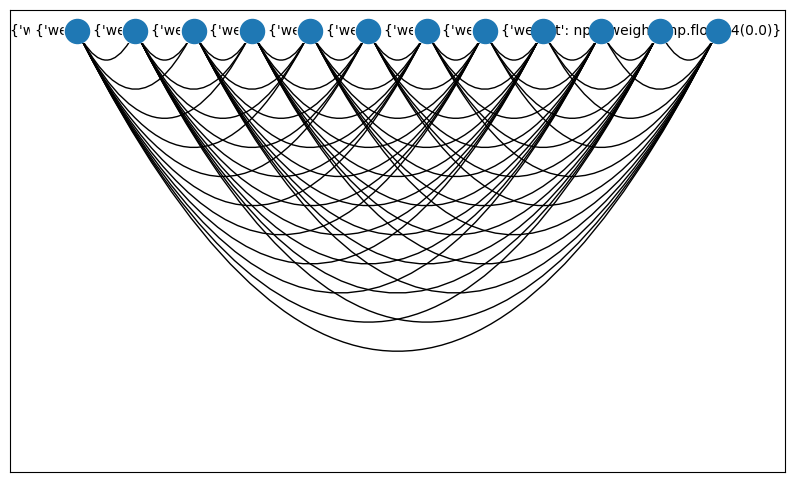

In [92]:
pos = {u: (u, 0) for u in graph.nodes()}

fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_nodes(graph, pos, ax=ax)
nx.draw_networkx_edges(
    graph, pos,
    connectionstyle="arc3,rad=1",
    arrows=True,
    ax=ax
)
edge_labels = nx.get_edge_attributes(graph, 'weight')

# Draw edge labels
nx.draw_networkx_edge_labels(graph, pos)

In [96]:
aug_graph = nx.DiGraph()

for u, v in graph.edges():
    for i in range(k):
        if (i == 0 and u !=0) or (i == k-1 and v != N-1) or (i > u):
            continue
        aug_graph.add_edge((i, u), (i + 1, v), weight=graph[u][v]['weight'])

for i in range(1, k):
    aug_graph.add_edge((i, N-1), (i+1, N-1), weight=0)

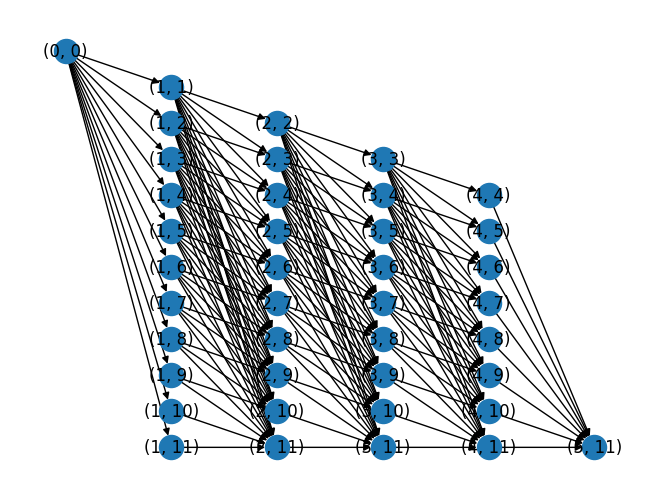

In [97]:
positions = {node: (node[0], N - node[1]) for node in aug_graph.nodes()}

nx.draw(aug_graph, pos=positions, with_labels=True)
#nx.draw_networkx_edge_labels(aug_graph, positions)

In [98]:
nx.shortest_path(aug_graph, (0, 0), (k, N-1), weight='weight')

[(0, 0), (1, 2), (2, 4), (3, 6), (4, 9), (5, 11)]

In [ ]:
N = 50
graph = nx.complete_graph(N)
for (u, v, data) in graph.edges(data=True):
    data['weight'] = abs(u-v)*np.log(abs(u-v))

costs = []
ks = range(1, N)
for k in tqdm(ks):
    aug_graph = nx.DiGraph()

    for u, v in graph.edges():
        for i in range(k):
            if (i == 0 and u !=0) or (i == k-1 and v != N-1) or (i > u):
                continue
            aug_graph.add_edge((i, u), (i + 1, v), weight=graph[u][v]['weight'])

    for i in range(1, k):
        aug_graph.add_edge((i, N-1), (i+1, N-1), weight=0)
    costs.append(nx.shortest_path_length(aug_graph, (0, 0), (k, N-1), weight='weight'))

100%|██████████| 49/49 [00:02<00:00, 20.70it/s]


Text(0.5, 1.0, 'Cost of the shortest path length less than k')

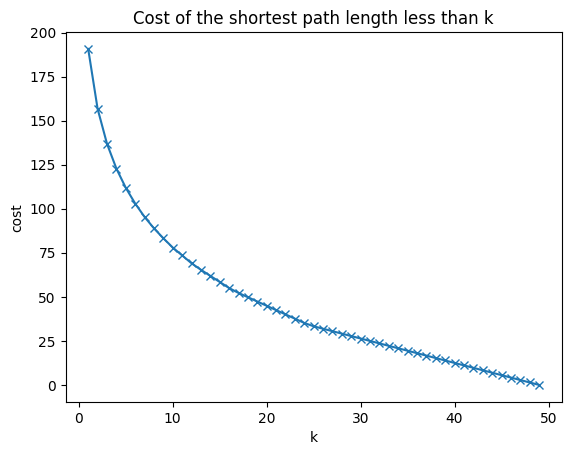

In [100]:
plt.plot(ks, costs, '-x')
plt.xlabel('k')
plt.ylabel('cost')
plt.title('Cost of the shortest path length less than k')